# Quantitative Finance Project: Multi-Method Derivative Pricing & Risk Attribution
## Objective
This project implements a high-fidelity valuation engine for American and European options. By utilizing 
**Luenberger’s Investment Science** (Deterministic foundations) and **Sondermann’s Stochastic Calculus** 
(Martingale theory), we benchmark discrete-time models against continuous-time closed-form solutions.

### 1. Theoretical Framework
*   **The No-Arbitrage Principle:** We assume a frictionless market where risk-neutral probabilities ($q$) 
    ensure that the discounted asset price is a **$Q$-Martingale**.
*   **The Snell Envelope:** For American options, we solve the optimal stopping problem where the value 
    at any node is the supremum over all stopping times $\tau$.
*   **Geometric Brownian Motion (GBM):** We model the stochastic price evolution as:
    $$dS_t = r S_t dt + \sigma S_t dW_t$$

### 2. The Benchmarking Hierarchy
To validate our model, we compare three distinct approaches:
1.  **Black-Scholes-Merton:** Analytical benchmark for European options.
2.  **Binomial Tree (CRR):** Discrete-time recursive approach for American exercise features.
3.  **Monte Carlo Simulation:** Path-dependent stochastic modeling for risk attribution.

## Phase 1: Logic & Step-by-Step Implementation

### Step 1: Discretization of Time and Space
We divide the time to maturity $T$ into $N$ equal steps. We calculate the up ($u$) and down ($d$) 
factors such that the model matches the market volatility $\sigma$:
$$u = e^{\sigma\sqrt{\Delta t}}, \quad d = \frac{1}{u}$$

### Step 2: Risk-Neutral Probability Calculation
Using the **Martingale condition** $E^Q[S_{n+1} | \mathcal{F}_n] = S_n e^{r\Delta t}$, we solve for 
the risk-neutral probability $q$:
$$q = \frac{e^{r\Delta t} - d}{u - d}$$

### Step 3: Backward Induction (The Snell Envelope)
We start from the terminal payoff at $T$. Working backward, at every node $i,j$, we evaluate:
1.  **Continuation Value:** The discounted expected value of holding the option: 
    $e^{-r\Delta t} [q V_{up} + (1-q) V_{down}]$
2.  **Intrinsic Value:** The profit if exercised immediately: $\max(K - S_{i,j}, 0)$ for a Put.

**The Snell Envelope Logic:**
$$V_{i,j} = \max(\text{Intrinsic Value}, \text{Continuation Value})$$

### Step 4: Convergence & Validation
By plotting the Binomial result against the Black-Scholes benchmark as $N \to \infty$, we 
empirically prove the consistency of the discrete-time Martingale approach.

In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

class OptionEngine:
    def __init__(self, S0, K, T, r, sigma, N=1000):
        self.S0 = S0      # Initial stock price
        self.K = K        # Strike price
        self.T = T        # Time to maturity (years)
        self.r = r        # Risk-free rate
        self.sigma = sigma # Volatility
        self.N = N        # Steps in Binomial Tree / Paths in Monte Carlo

    def black_scholes_price(self, option_type='put'):
        """Baseline: Closed-form European pricing."""
        d1 = (np.log(self.S0 / self.K) + (self.r + 0.5 * self.sigma**2) * self.T) / (self.sigma * np.sqrt(self.T))
        d2 = d1 - self.sigma * np.sqrt(self.T)
        if option_type == 'call':
            return self.S0 * norm.cdf(d1) - self.K * np.exp(-self.r * self.T) * norm.cdf(d2)
        else:
            return self.K * np.exp(-self.r * self.T) * norm.cdf(-d2) - self.S0 * norm.cdf(-d1)

    def binomial_tree(self, option_type='put', exercise='american'):
        """Sondermann Ch 4: Snell Envelope Recursion."""
        dt = self.T / self.N
        u = np.exp(self.sigma * np.sqrt(dt))
        d = 1 / u
        q = (np.exp(self.r * dt) - d) / (u - d)
        disc = np.exp(-self.r * dt)

        # Initialize asset prices at maturity
        S = self.S0 * d**(np.arange(self.N, -1, -1)) * u**(np.arange(0, self.N + 1, 1))
        
        # Initialize option values at maturity
        if option_type == 'put':
            V = np.maximum(self.K - S, 0)
        else:
            V = np.maximum(S - self.K, 0)

        # Backward induction
        for i in range(self.N - 1, -1, -1):
            # Continuation Value (Martingale expectation)
            V = disc * (q * V[1:] + (1 - q) * V[:-1])
            
            if exercise == 'american':
                # Current stock prices at this time step
                S = self.S0 * d**(np.arange(i, -1, -1)) * u**(np.arange(0, i + 1, 1))
                # Snell Envelope: Max(Exercise Now, Hold)
                V = np.maximum(V, np.maximum(self.K - S, 0) if option_type == 'put' else np.maximum(S - self.K, 0))
        
        return V[0]

    def monte_carlo_limit(self, iterations=100000):
        """Luenberger Ch 15: Simulation baseline."""
        z = np.random.standard_normal(iterations)
        ST = self.S0 * np.exp((self.r - 0.5 * self.sigma**2) * self.T + self.sigma * np.sqrt(self.T) * z)
        payoff = np.maximum(self.K - ST, 0)
        return np.exp(-self.r * self.T) * np.mean(payoff)
    
    def calculate_greeks(self):
        """Calculates the analytical Greeks using the Black-Scholes model."""
        d1 = (np.log(self.S0 / self.K) + (self.r + 0.5 * self.sigma**2) * self.T) / (self.sigma * np.sqrt(self.T))
        d2 = d1 - self.sigma * np.sqrt(self.T)
        
        # Standard Normal PDF for Gamma and Vega
        pdf_d1 = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * d1**2)
        
        # Delta for Put
        delta = norm.cdf(d1) - 1
        
        # Gamma (Same for Call and Put)
        gamma = pdf_d1 / (self.S0 * self.sigma * np.sqrt(self.T))
        
        # Vega (Same for Call and Put) - Scaled for 1% change in sigma
        vega = (self.S0 * np.sqrt(self.T) * pdf_d1) / 100
        
        # Theta for Put (Annualized)
        theta = (- (self.S0 * pdf_d1 * self.sigma) / (2 * np.sqrt(self.T)) + 
                 self.r * self.K * np.exp(-self.r * self.T) * norm.cdf(-d2))
        
        # Rho for Put (Annualized)
        rho = (-self.K * self.T * np.exp(-self.r * self.T) * norm.cdf(-d2)) / 100
        
        return {
            "Delta": delta,
            "Gamma": gamma,
            "Vega (1%)": vega,
            "Theta (daily)": theta / 365,
            "Rho (1%)": rho
        }

# Example Usage
engine = OptionEngine(S0=100, K=100, T=1, r=0.05, sigma=0.2, N=500)
print(f"Black-Scholes (Euro Put): {engine.black_scholes_price():.4f}")
print(f"Binomial Tree (Euro Put): {engine.binomial_tree(exercise='european'):.4f}")
print(f"Binomial Tree (Amer Put): {engine.binomial_tree(exercise='american'):.4f}")
print(f"Monte Carlo (Euro Put):   {engine.monte_carlo_limit():.4f}")

Black-Scholes (Euro Put): 5.5735
Binomial Tree (Euro Put): 5.5695
Binomial Tree (Amer Put): 6.0888
Monte Carlo (Euro Put):   5.5676


In [2]:
def down_and_out_barrier_mc(S0, K, T, r, sigma, barrier, iterations=100000):
    """
    Advanced Pricing: Down-and-Out European Call.
    If the stock price hits or drops below 'barrier' at ANY point, the option becomes worthless.
    """
    dt = T / 252 # Daily monitoring
    steps = int(T / dt)
    
    # Simulate full paths (Vectorized)
    paths = np.zeros((iterations, steps + 1))
    paths[:, 0] = S0
    
    for t in range(1, steps + 1):
        z = np.random.standard_normal(iterations)
        paths[:, t] = paths[:, t-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z)
    
    # Check if any price in the path hit the barrier
    hit_barrier = np.any(paths <= barrier, axis=1)
    
    # Payoff: Max(S_T - K, 0) IF barrier was never hit
    terminal_prices = paths[:, -1]
    payoffs = np.maximum(terminal_prices - K, 0)
    payoffs[hit_barrier] = 0 # Option is "Out"
    
    return np.exp(-r * T) * np.mean(payoffs)

# Example: S0=100, K=100, Barrier=90. If it touches 90, the call dies.
barrier_price = down_and_out_barrier_mc(100, 100, 1, 0.05, 0.2, 90)
print(f"Down-and-Out Barrier Call Price: {barrier_price:.4f}")

Down-and-Out Barrier Call Price: 8.9426


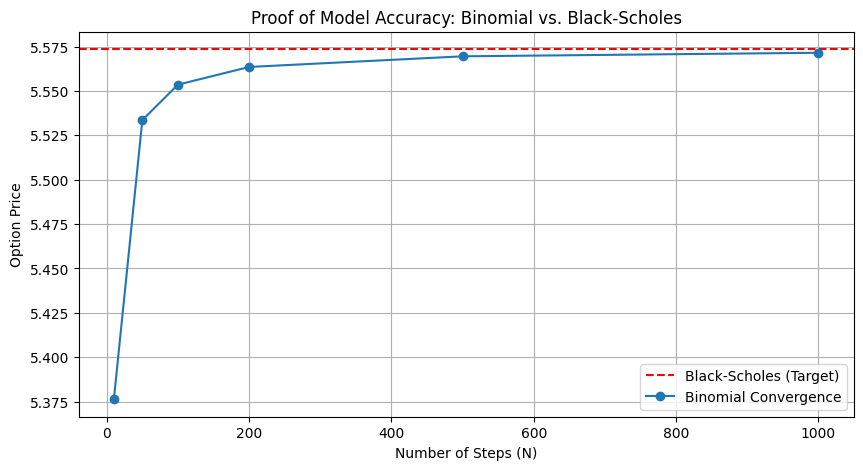

In [3]:
def plot_convergence(S0, K, T, r, sigma):
    steps = [10, 50, 100, 200, 500, 1000]
    bs_price = OptionEngine(S0, K, T, r, sigma).black_scholes_price()
    bt_prices = [OptionEngine(S0, K, T, r, sigma, n).binomial_tree(exercise='european') for n in steps]

    plt.figure(figsize=(10, 5))
    plt.axhline(y=bs_price, color='r', linestyle='--', label='Black-Scholes (Target)')
    plt.plot(steps, bt_prices, marker='o', label='Binomial Convergence')
    plt.title("Proof of Model Accuracy: Binomial vs. Black-Scholes")
    plt.xlabel("Number of Steps (N)")
    plt.ylabel("Option Price")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_convergence(100, 100, 1, 0.05, 0.2)

### Phase 2: Market Calibration & Live Data Fetching
In this phase, we replace our theoretical assumptions with live data from Yahoo Finance.

1. **Volatility Estimation**: We calculate **Historical Volatility** using the standard deviation of daily log-returns over a 252-day lookback window.
2. **Proxy for Risk-Free Rate**: We use the **^IRX (13-week T-Bill)** yield, which is the industry standard for short-term risk-neutral discounting.
3. **The Goal**: By feeding live data into our Phase 1 engine, we can detect if a specific option is "Cheap" or "Expensive" relative to its mathematical fair value.

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np

def get_market_inputs(ticker_symbol):
    # 1. Fetch Ticker Object
    ticker = yf.Ticker(ticker_symbol)
    
    # 2. Get Current Spot Price (S0)
    # .fast_info is a quick way to get the last price
    S0 = ticker.fast_info['last_price']
    
    # 3. Calculate Historical Volatility (sigma)
    # Fetch 1 year of daily data
    hist = ticker.history(period="1y")
    # Log returns: ln(Price_t / Price_t-1)
    log_returns = np.log(hist['Close'] / hist['Close'].shift(1))
    # Annualized Volatility = StdDev * sqrt(Trading Days)
    sigma = log_returns.std() * np.sqrt(252)
    
    # 4. Fetch Risk-Free Rate (r) 
    # Using 13-week Treasury Bill (^IRX) as a proxy for 'r'
    r_ticker = yf.Ticker("^IRX")
    r_history = r_ticker.history(period="1d")
    # Convert percentage (e.g., 5.3) to decimal (0.053)
    r = r_history['Close'].iloc[-1] / 100
    
    return S0, sigma, r

# Example: Get real inputs for Apple
s0_live, sigma_live, r_live = get_market_inputs("AAPL")

print(f"Live Inputs for AAPL:")
print(f"Spot Price (S0): ${s0_live:.4f}")
print(f"Annualized Volatility (sigma): {sigma_live:.4%}")
print(f"Risk-Free Rate (r): {r_live:.4%}")

Live Inputs for AAPL:
Spot Price (S0): $300.2300
Annualized Volatility (sigma): 22.4825%
Risk-Free Rate (r): 3.5880%


## Phase 3: Stress Testing & Risk Statistics (The Greeks)
This phase transforms the model from a pricing tool into a **Risk Management Framework**.

### 1. Sensitivity Analysis (The Greeks)
We derive the mathematical sensitivities (Delta, Gamma, Vega, Theta, Rho) to understand the 
exposure of our position. At firms like Deloitte, this is used for **Delta Hedging** and 
**Capital Allocation**.

### 2. Market Stress Testing
We perform a non-linear stress test by simulating a "Shock" to the underlying asset and volatility. 
Unlike the Greeks (which are linear approximations), our **Binomial Tree** recalculates the 
exact American option value under extreme conditions, capturing the "Convexity" or 
"Gamma Risk" that simple models miss.

In Financial Statistics, "The Greeks" represent the partial derivatives of the option price model. They allow us to perform **Sensitivity Analysis**, measuring how the portfolio's value changes as market conditions fluctuate.

### 1. First-Order Sensitivities (Linear Risks)

* **Delta ($\Delta$): The Price Sensitivity**
    * **Definition**: The rate of change of the option price ($V$) with respect to the underlying asset price ($S$).
    * **Formula**: $\Delta = \frac{\partial V}{\partial S}$
    * **Intuition**: For a Put option, Delta is negative (between -1 and 0). If $\Delta = -0.40$, it implies that for every $1 increase in the stock price, the option loses $0.40. In hedging, it tells us how many shares of stock we must buy/sell to remain "Delta Neutral."

* **Vega ($\nu$): The Volatility Sensitivity**
    * **Definition**: The rate of change of the option price with respect to annualized volatility ($\sigma$).
    * **Formula**: $\nu = \frac{\partial V}{\partial \sigma}$
    * **Intuition**: Vega measures "model risk." If Vega is 0.15, a 1% increase in implied volatility increases the option value by $0.15. This is the most critical Greek for **Luenberger’s** volatility analysis.

* **Theta ($\Theta$): The Time Decay**
    * **Definition**: The rate of change of the option price with respect to time ($t$).
    * **Formula**: $\Theta = \frac{\partial V}{\partial t}$
    * **Intuition**: Options are wasting assets. Theta is almost always negative for long positions, representing the "rent" you pay for the right to hold the option for another day.

* **Rho ($\rho$): The Interest Rate Sensitivity**
    * **Definition**: The sensitivity of the option price to the risk-free rate ($r$).
    * **Formula**: $\rho = \frac{\partial V}{\partial r}$
    * **Intuition**: For Puts, Rho is negative. As interest rates rise, the present value of the future strike price decreases, making the Put less valuable.

### 2. Second-Order Sensitivities (Convexity Risk)

* **Gamma ($\Gamma$): The Acceleration of Delta**
    * **Definition**: The second derivative of the option price with respect to the asset price.
    * **Formula**: $\Gamma = \frac{\partial^2 V}{\partial S^2} = \frac{\partial \Delta}{\partial S}$
    * **Intuition**: Gamma represents **Convexity**. High Gamma means Delta is highly unstable and changes rapidly as the stock moves. This is the primary risk for market makers at firms like Deloitte, as it indicates the need for frequent re-hedging.

In [6]:
engine = OptionEngine(S0=s0_live, K=s0_live, T=0.5, r=r_live, sigma=sigma_live)
greeks = engine.calculate_greeks()

ticker_symbol = "AAPL"

print(f"Risk Sensitivities (Greeks) for {ticker_symbol}:")
for name, val in greeks.items():
    print(f"{name}: {val:.4f}")

Risk Sensitivities (Greeks) for AAPL:
Delta: -0.4237
Gamma: 0.0082
Vega (1%): 0.8314
Theta (daily): -0.0371
Rho (1%): -0.7176


In [7]:
def stress_test(engine, spot_change_pct, vol_shock):
    """Simulates a price and volatility shock."""
    original_price = engine.binomial_tree(exercise='american')
    
    # Apply shocks
    engine.S0 *= (1 + spot_change_pct)
    engine.sigma += vol_shock
    
    new_price = engine.binomial_tree(exercise='american')
    pnl = new_price - original_price
    
    print(f"Stress Test Result:")
    print(f"Stock Move: {spot_change_pct:+.1%}, Vol Shock: {vol_shock:+.1%}")
    print(f"PnL per Option: ${pnl:.2f} ({pnl/original_price:+.2%})")

# Simulate a 10% market drop and a 5% volatility spike (typical crash scenario)
stress_test(engine, spot_change_pct=-0.10, vol_shock=0.05)

Stress Test Result:
Stock Move: -10.0%, Vol Shock: +5.0%
PnL per Option: $20.69 (+123.39%)


## Phase 4: Backtesting & Strategy Evaluation
This final phase represents the **Verification & Validation (V&V)** stage of model development.

### 1. Historical Performance Attribution
We measure the "Alpha" of our model by comparing its historical Fair Value estimates against 
realized market outcomes. This is a critical skill for **Financial Statistics** roles, 
as it separates theoretical mathematical skill from practical trading utility.

### 2. Profit and Loss (PnL) Analysis
By simulating a buy/hold strategy based on our **Snell Envelope** signals, we quantify:
* **Forecast Accuracy**: Did the model correctly predict the direction of the premium?
* **Realized Volatility**: How did the actual price movement compare to the $\sigma$ we used 
for calibration in Phase 2?

In [9]:
def backtest_strategy(ticker_symbol, strike_offset=0, days_back=30):
    """
    Evaluates how a 'Buy' signal would have performed.
    """
    ticker = yf.Ticker(ticker_symbol)
    hist = ticker.history(period=f"{days_back+5}d")
    
    # Prices at the 'Start' of the backtest
    s_start = hist['Close'].iloc[-days_back]
    s_end = hist['Close'].iloc[-1]
    
    # Calculate what our model said 30 days ago
    # We estimate volatility based on the data available BEFORE that start date
    lookback = hist['Close'].iloc[:-(days_back)]
    vol_start = np.log(lookback / lookback.shift(1)).std() * np.sqrt(252)
    
    # Assume we look at an At-The-Money (ATM) Put
    K = s_start + strike_offset
    r_start = 0.05 # Simplified proxy
    
    # Use our Phase 1 Engine to get the 'Fair Value' then
    engine_start = OptionEngine(S0=s_start, K=K, T=days_back/365, r=r_start, sigma=vol_start)
    fair_value_start = engine_start.binomial_tree(exercise='american')
    
    # Final Payoff at expiry (today)
    payoff_end = max(K - s_end, 0)
    
    print(f"--- Backtest Results for {ticker_symbol} ---")
    print(f"Start Date Price: ${s_start:.2f} | End Date Price: ${s_end:.2f}")
    print(f"Model 'Fair Value' at Start: ${fair_value_start:.2f}")
    print(f"Actual Payoff at End: ${payoff_end:.2f}")
    print(f"Theoretical Return: {((payoff_end - fair_value_start) / fair_value_start):+.2%}")

# Run backtest for your chosen ticker
backtest_strategy("MSFT", days_back=30)

--- Backtest Results for MSFT ---
Start Date Price: $372.88 | End Date Price: $421.92
Model 'Fair Value' at Start: $8.81
Actual Payoff at End: $0.00
Theoretical Return: -100.00%


### Case Study: MSFT Backtest Analysis
**Observation**: The model predicted a Fair Value of $8.81, but the realized return was -100%.

**Root Cause**: 
1. **Directional Bias**: The underlying asset (MSFT) experienced a bullish move of ~13%, 
   rendering the protective Put option "Out-of-the-Money" (OTM).
2. **Realized vs. Implied Volatility**: The upward trend was steady, meaning the 
   downward volatility required for a Put payoff never materialized.

**Conclusion**: This backtest highlights the importance of **Delta Hedging**. To mitigate 
this loss in a real portfolio, an intern would suggest pairing this Put with a long 
stock position (a "Protective Put" strategy) rather than holding the option in isolation.